### Quantization Model

In [1]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.models import load_model

# Load original trained model
model_fp32 = load_model("arduino_cnn_model.h5")

# Prepare representative dataset function (for calibration)
(x_train, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

def representative_dataset():
    for i in range(100):
        yield [x_train[i:i+1]]

# Convert model to TFLite INT8
converter = tf.lite.TFLiteConverter.from_keras_model(model_fp32)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Ensure full int8 quantization
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

# Convert
tflite_quant_model = converter.convert()

# Save directory
output_dir = "exported_models"
os.makedirs(output_dir, exist_ok=True)

# Save TFLite model
model_path = os.path.join(output_dir, "arduino_cnn_model_quant.tflite")
with open(model_path, "wb") as f:
    f.write(tflite_quant_model)

print(f"✅ Quantized model exported to: {model_path}")


INFO:tensorflow:Assets written to: /var/folders/05/m23tqns511394yns05t046fr0000gn/T/tmpx_lgegm0/assets


INFO:tensorflow:Assets written to: /var/folders/05/m23tqns511394yns05t046fr0000gn/T/tmpx_lgegm0/assets


Saved artifact at '/var/folders/05/m23tqns511394yns05t046fr0000gn/T/tmpx_lgegm0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  13071700176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071700368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071702480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071703824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071701712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071701136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071704592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071704784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071703632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13071706896:

/opt/anaconda3/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1752250923.096467  176517 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1752250923.097521  176517 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-07-11 18:22:03.099208: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/05/m23tqns511394yns05t046fr0000gn/T/tmpx_lgegm0
2025-07-11 18:22:03.100383: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-07-11 18:22:03.100391: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/05/m23tqns511394yns05t046fr0000gn/T/tmpx_lgegm0
I0000 00:00:1752250923.113299  176517 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-07-11 18:22:03.115683: I tensorflow

✅ Quantized model exported to: exported_models/arduino_cnn_model_quant.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


### Comparision 

In [2]:
import os
 
fp32_size = os.path.getsize("arduino_cnn_model.h5") / 1024  # in KB
int8_size = os.path.getsize("arduino_cnn_model_quant.tflite") / 1024  # in KB
 
print(f"Original Model Size: {fp32_size:.2f} KB")
print(f"Quantized Model Size: {int8_size:.2f} KB")
print(f"Compression Ratio: {fp32_size / int8_size:.2f}x")

FileNotFoundError: [Errno 2] No such file or directory: 'arduino_cnn_model_quant.tflite'

### Evaluation 

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import classification_report
import os
 
# Load CIFAR-10 test dataset
(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype(np.float32) / 255.0
y_test = y_test.flatten()
 
# Load TFLite quantized model
interpreter = tf.lite.Interpreter(model_path="arduino_cnn_model_quant.tflite")
interpreter.allocate_tensors()
 
# Get input/output details
input_index = interpreter.get_input_details()[0]['index']
output_index = interpreter.get_output_details()[0]['index']
input_scale, input_zero_point = interpreter.get_input_details()[0]['quantization']
 
# Convert test images to uint8 using quantization parameters
x_test_uint8 = (x_test / input_scale + input_zero_point).astype(np.uint8)
 
# Run inference
y_pred = []
for i in range(len(x_test_uint8)):
    input_tensor = x_test_uint8[i:i+1]
    interpreter.set_tensor(input_index, input_tensor)
    interpreter.invoke()
    output = interpreter.get_tensor(output_index)
    y_pred.append(np.argmax(output))
 
# Evaluate accuracy
accuracy = np.mean(np.array(y_pred) == y_test)
print(f"Quantized Model Accuracy: {accuracy:.4f}")
 
# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[
        'airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck'
    ]
))

/opt/anaconda3/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized Model Accuracy: 0.6130

Classification Report:
              precision    recall  f1-score   support

    airplane       0.63      0.64      0.64      1000
  automobile       0.77      0.69      0.73      1000
        bird       0.56      0.43      0.49      1000
         cat       0.47      0.33      0.39      1000
        deer       0.57      0.50      0.53      1000
         dog       0.68      0.36      0.47      1000
        frog       0.52      0.87      0.65      1000
       horse       0.66      0.71      0.68      1000
        ship       0.66      0.79      0.72      1000
       truck       0.63      0.81      0.71      1000

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.60     10000
weighted avg       0.62      0.61      0.60     10000



#### Visualizing the results 

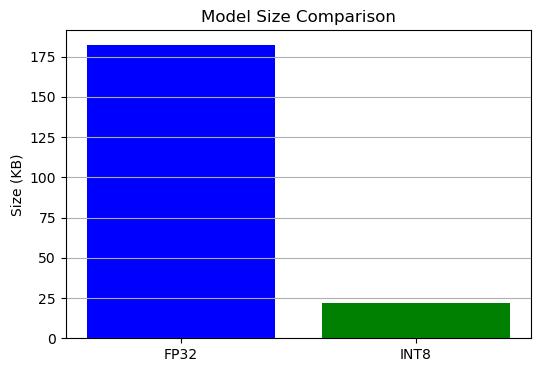

In [ ]:
import matplotlib.pyplot as plt

# Model sizes (in KB)
fp32_size = os.path.getsize("arduino_cnn_model.h5") / 1024
int8_size = os.path.getsize("arduino_cnn_model_quant.tflite") / 1024

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar(["FP32", "INT8"], [fp32_size, int8_size], color=['blue', 'green'])
plt.title("Model Size Comparison")
plt.ylabel("Size (KB)")
plt.grid(True, axis='y')
plt.show()

### Confusion Matrix

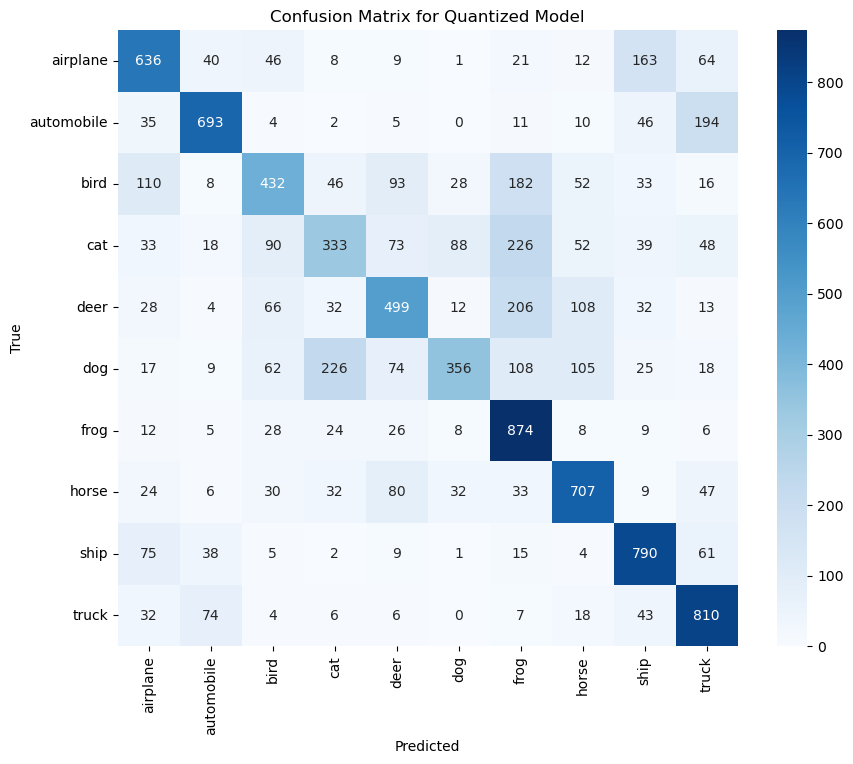

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[
                'airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck'
            ],
            yticklabels=[
                'airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck'
            ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Quantized Model")
plt.show()


### Precision Recall Curve 

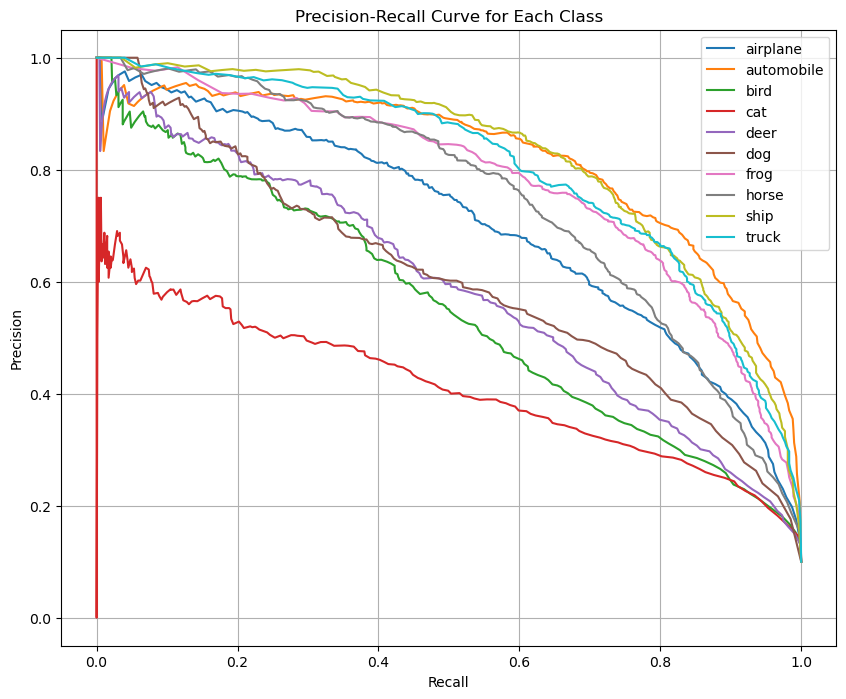

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# Convert labels to one-hot
y_test_bin = label_binarize(y_test, classes=np.arange(10))
y_pred_probs = []

# Re-run inference to collect full probability output
for i in range(len(x_test_uint8)):
    interpreter.set_tensor(input_index, x_test_uint8[i:i+1])
    interpreter.invoke()
    output = interpreter.get_tensor(output_index)[0]
    y_pred_probs.append(output)

y_pred_probs = np.array(y_pred_probs)

# Plot Precision-Recall curves for each class
plt.figure(figsize=(10, 8))
for i in range(10):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend([
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
])
plt.grid(True)
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized Model Accuracy: 0.6130

Classification Report:
              precision    recall  f1-score   support

    airplane       0.63      0.64      0.64      1000
  automobile       0.77      0.69      0.73      1000
        bird       0.56      0.43      0.49      1000
         cat       0.47      0.33      0.39      1000
        deer       0.57      0.50      0.53      1000
         dog       0.68      0.36      0.47      1000
        frog       0.52      0.87      0.65      1000
       horse       0.66      0.71      0.68      1000
        ship       0.66      0.79      0.72      1000
       truck       0.63      0.81      0.71      1000

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.60     10000
weighted avg       0.62      0.61      0.60     10000


✅ Report saved in current directory as 'quantized_model_report.txt'
